# Data Load & Cleaning 

In [47]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
import pickle

In [48]:
df = pd.read_csv('INDUSTRY.csv')

In [49]:
df.shape

(15000, 12)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  object 
 2   industry                15000 non-null  object 
 3   country                 15000 non-null  object 
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  object 
 11  region                  15000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


In [51]:
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')

In [52]:
df.dtypes

id                                 int64
company_name                      object
industry                          object
country                           object
employee_count                     int64
annual_revenue_million           float64
profit_margin_percent            float64
founded_year                       int64
customer_count                     int64
market_rating                    float64
created_date              datetime64[ns]
region                            object
dtype: object

In [53]:
df= df.drop(columns=['id'])

In [54]:
df.isnull().sum()

company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

In [56]:
df.describe()

,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000
mean,2606.862067,549.732707,25.012019,2004.374000,50449.251867,2.513780,2025-01-28 08:41:57.120000
min,100.000000,50.160000,5.000000,1990.000000,500.000000,0.000000,2024-01-01 00:00:00
25%,1379.000000,299.915000,15.050000,1997.000000,25676.250000,1.200000,2024-07-14 00:00:00
50%,2587.000000,543.920000,24.910000,2004.000000,50726.500000,2.500000,2025-01-28 00:00:00
75%,3839.000000,797.570000,35.100000,2012.000000,75271.250000,3.800000,2025-08-12 00:00:00
max,5099.000000,1049.960000,45.000000,2019.000000,100495.000000,5.000000,2026-02-28 00:00:00
std,1430.562513,288.244128,11.526187,8.606687,28744.638830,1.447998,NaN


In [57]:
df.head(5)

,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,2025-10-13,Asia
1,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,2025-12-01,Europe
2,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,2025-05-04,North America
3,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,2026-02-01,North America
4,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,2025-06-29,Asia


In [58]:
numerical_cols = ['employee_count', 'annual_revenue_million',
                  'profit_margin_percent', 'founded_year',
                  'customer_count', 'market_rating']

categorical_cols = ['industry', 'country', 'region']

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [59]:
print("=" * 65)
print("  NUMERICAL VARIABLE STATISTICS")
print("=" * 65)

stats_rows = []
for col in numerical_cols:
    s = df[col]
    stats_rows.append({
        'Column'   : col,
        'Skewness' : round(s.skew(), 4),
        'Kurtosis' : round(s.kurt(), 4),
    })

stats_df = pd.DataFrame(stats_rows).set_index('Column')
print(stats_df.to_string())
print()

  NUMERICAL VARIABLE STATISTICS
                        Skewness  Kurtosis
Column                                    
employee_count            0.0024   -1.1877
annual_revenue_million    0.0273   -1.1871
profit_margin_percent     0.0026   -1.2026
founded_year              0.0206   -1.1896
customer_count           -0.0049   -1.1947
market_rating            -0.0200   -1.2058



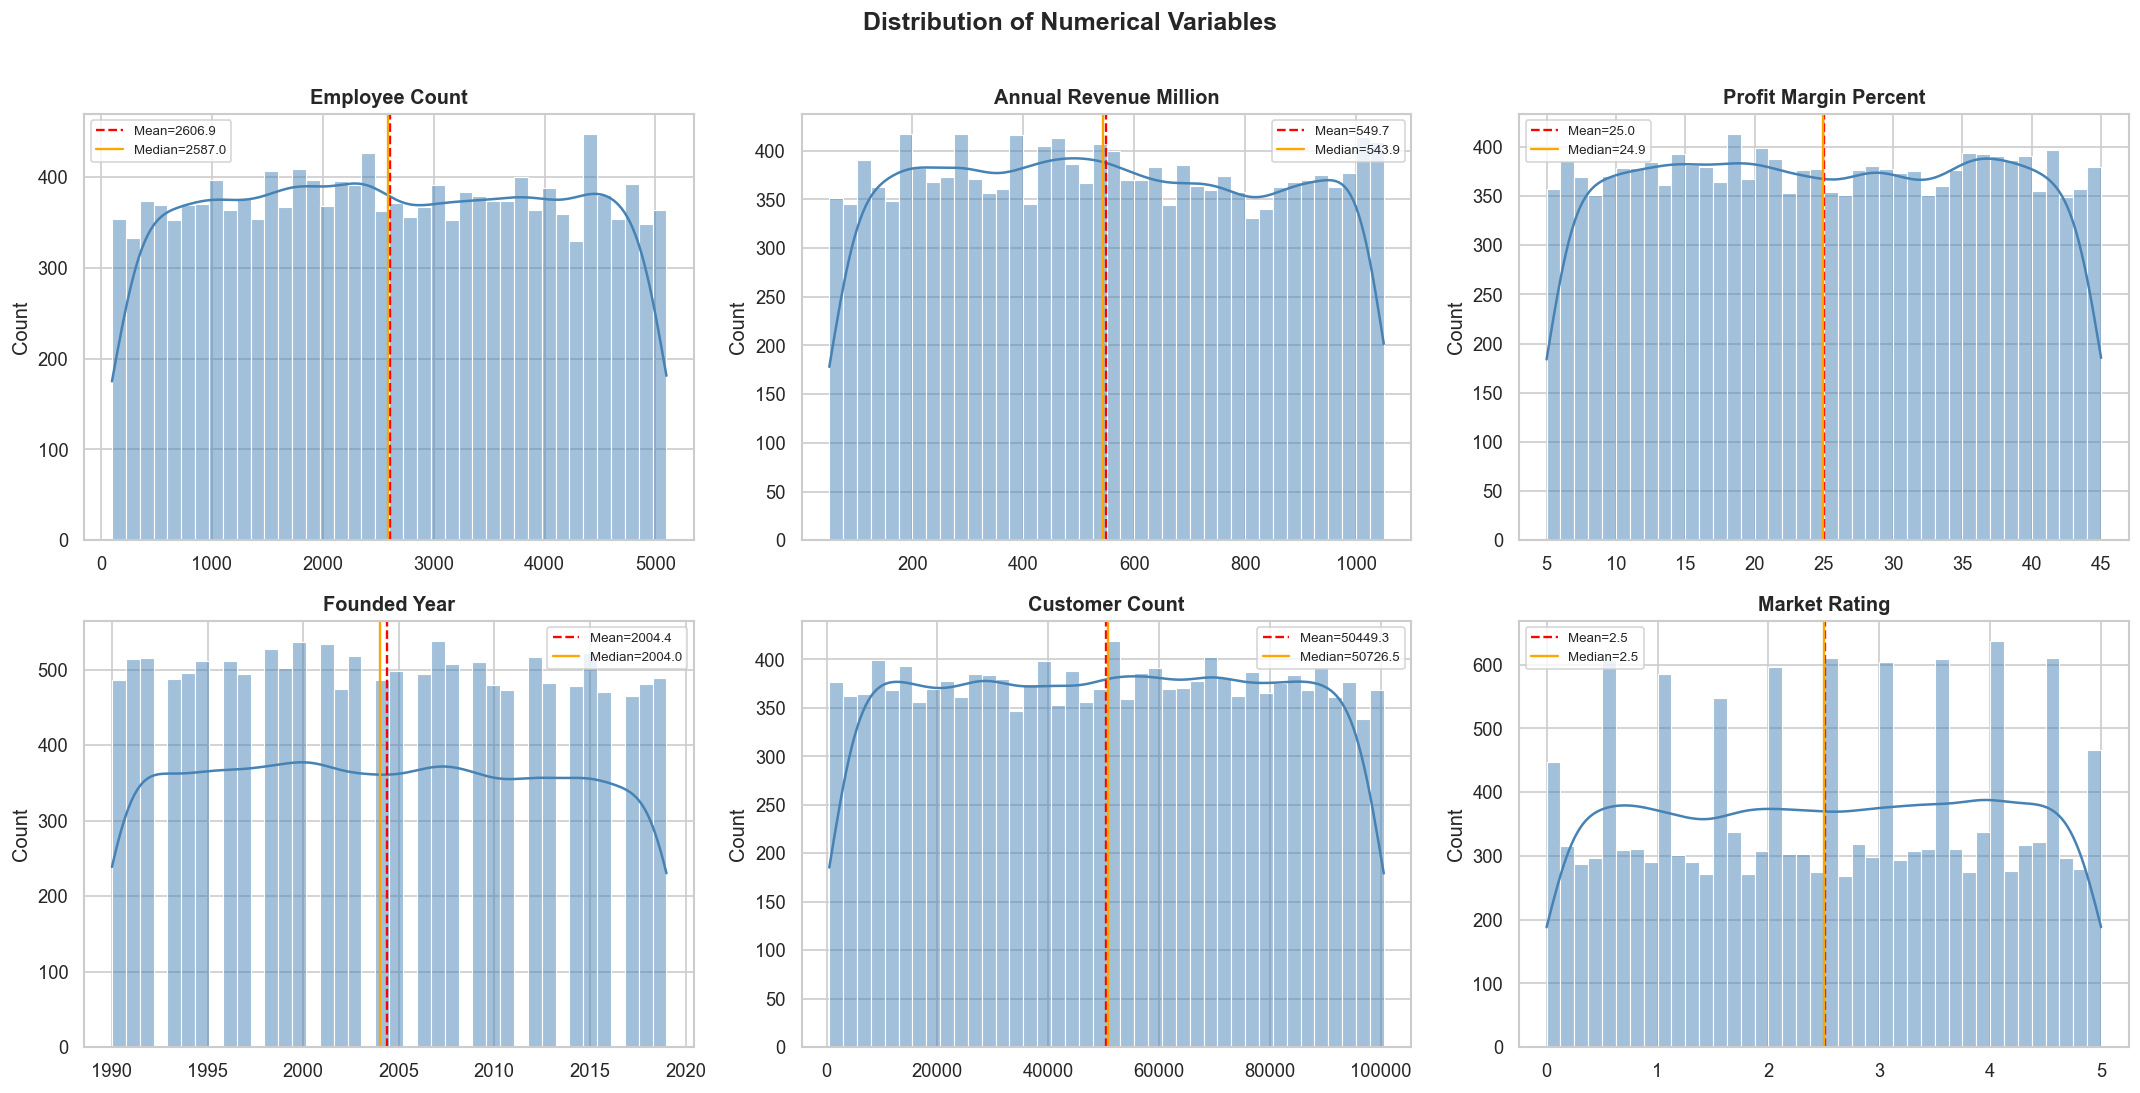

In [60]:
# =============================================================================
# DISTRIBUTION PLOTS — Numerical (Histogram + KDE)
# =============================================================================
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

import math
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(6 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', bins=40)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.4, label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-',  linewidth=1.4, label=f'Median={df[col].median():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Variables', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Insights : 

Across almost all metrics—Employee Count, Revenue, and Customer Count—the data shows a uniform distribution. This means the business or industry has a very consistent spread of small, medium, and large-scale operations without any extreme "gaps."

Companies range from very small (near 0 employees) to large (5,000 employees).

The "Market Rating" shows frequent peaks at whole numbers (1, 2, 3, 4, 5). The overall average rating is 2.5, which is exactly in the middle. This suggests there is significant room for improvement in customer satisfaction to push that average toward a 4 or 5.

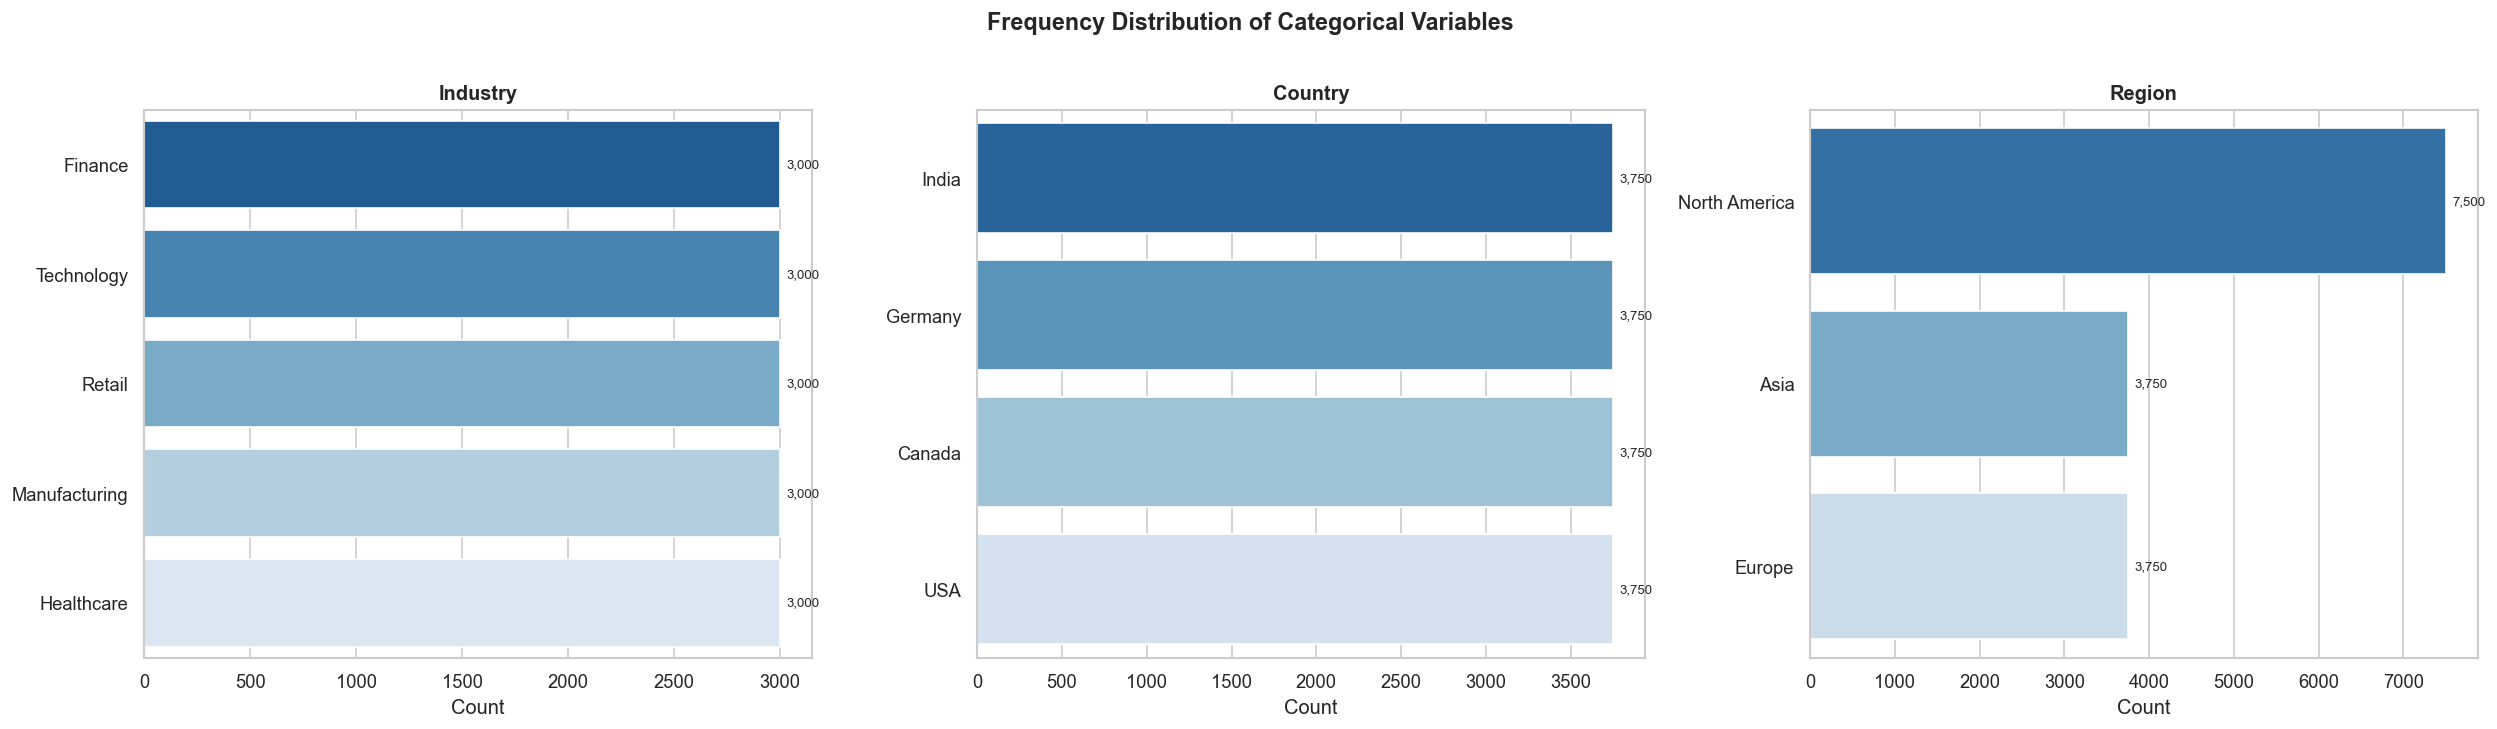

In [61]:
# =============================================================================
# FREQUENCY DISTRIBUTIONS — Categorical
# =============================================================================
fig, axes = plt.subplots(1, len(categorical_cols),
                         figsize=(7 * len(categorical_cols), 6))

for ax, col in zip(axes, categorical_cols):
    freq = df[col].value_counts()
    # Show top 15 for readability if many categories
    if len(freq) > 15:
        freq = freq.head(15)
        title_suffix = ' (Top 15)'
    else:
        title_suffix = ''

    sns.barplot(x=freq.values, y=freq.index, ax=ax,
                palette='Blues_r', orient='h')
    ax.set_title(col.replace('_', ' ').title() + title_suffix,
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
    ax.set_ylabel('')

    # Annotate bars
    for bar, val in zip(ax.patches, freq.values):
        ax.text(bar.get_width() + freq.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=8)

plt.suptitle('Frequency Distribution of Categorical Variables',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Insights :

The dataset is perfectly balanced across five key sectors: Finance, Technology, Retail, Manufacturing, and Healthcare.

Each industry has exactly 3,000 entries. This indicates a highly diversified business portfolio or study, meaning the overall performance isn't overly dependent on a single sector.

Each country shows a count of approximately 3,750, suggesting that the business has successfully established an identical scale of operations or data collection in each of these diverse international markets.

North American Focus: While the country-level data is balanced, the North America region shows a massive lead with 7,500 entries.

North America has double the presence of Asia (3,750) or Europe (3,750). This implies that North America is the primary hub for the business.

# =============================================================================
# OUTLIER DETECTION — Boxplots
# =============================================================================

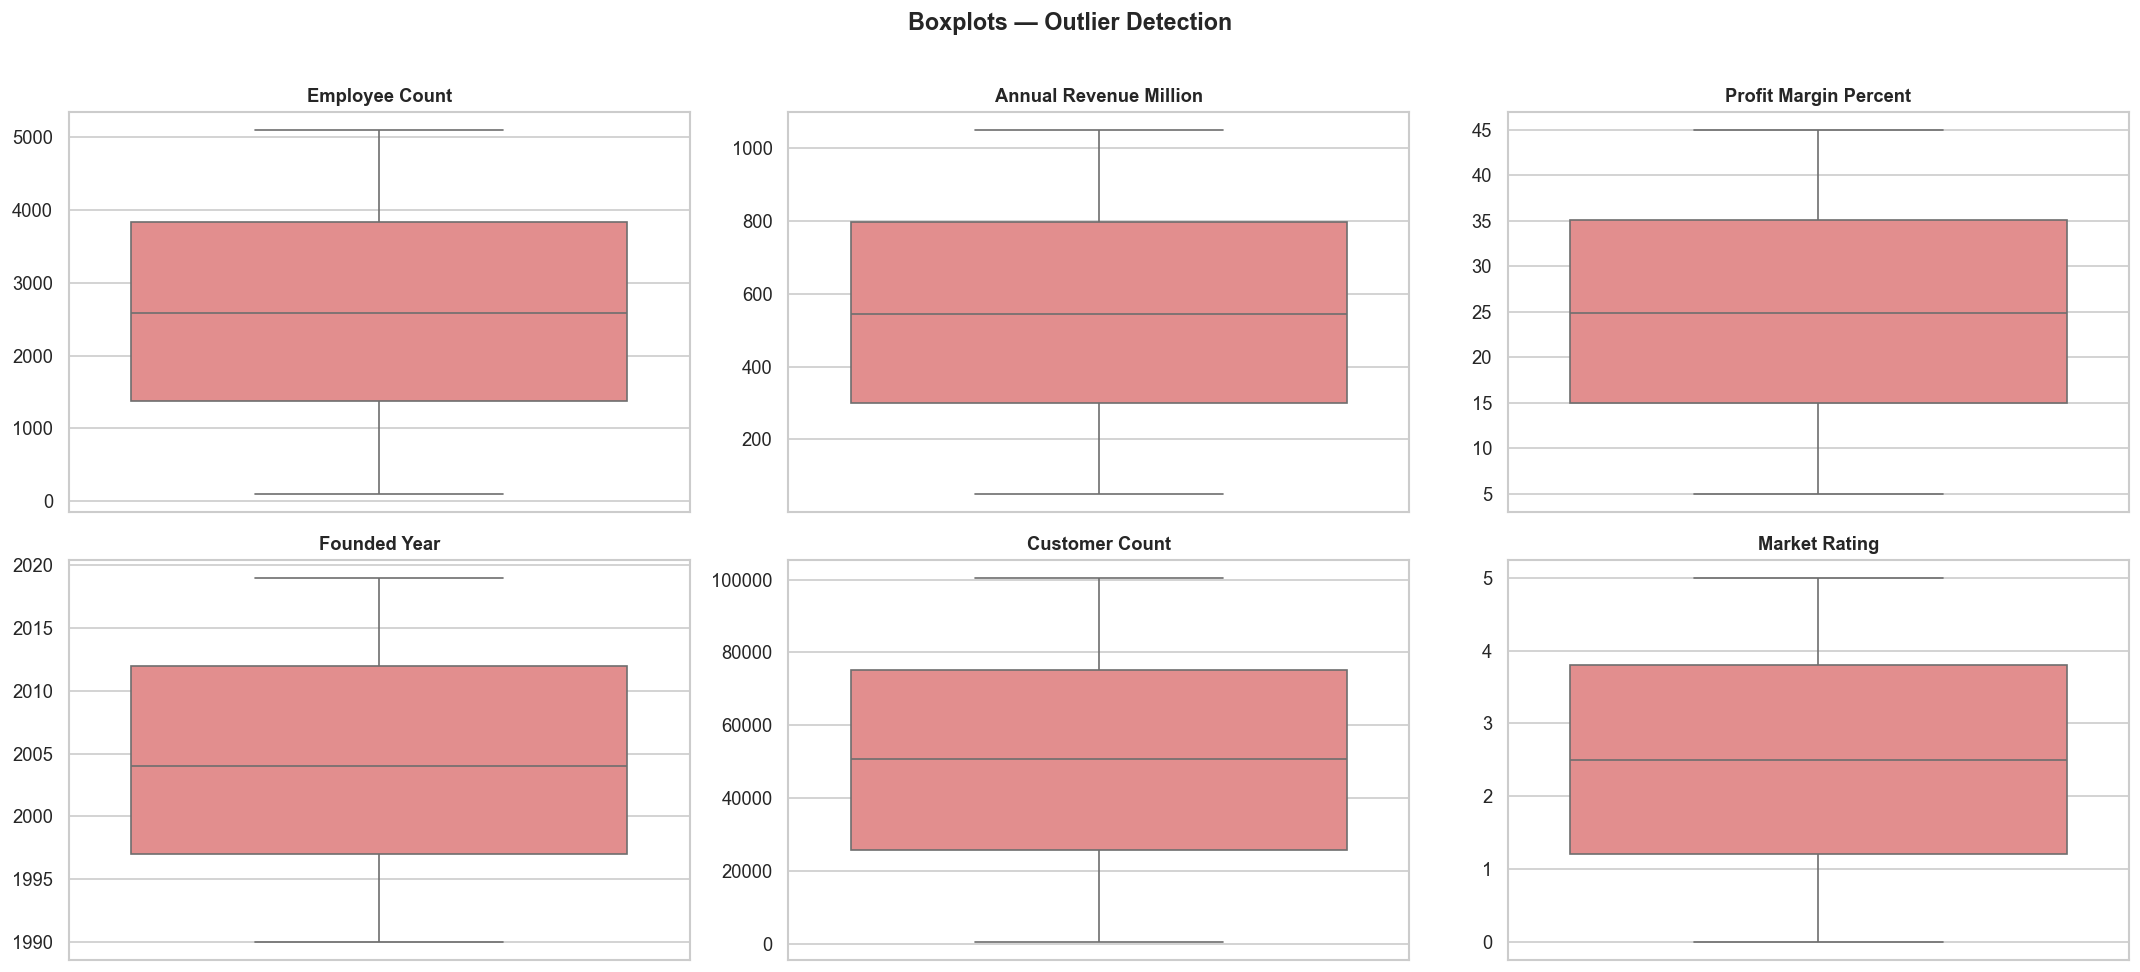

In [62]:
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color='lightcoral',
                flierprops=dict(marker='o', markerfacecolor='red',
                                markersize=3, alpha=0.5))
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# =============================================================================
# OUTLIER DETECTION — IQR Method
# =============================================================================

In [63]:
print("=" * 65)
print("  OUTLIER COUNTS — IQR METHOD")
print("=" * 65)

iqr_results = []
for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = round(100 * n_out / len(df), 2)
    iqr_results.append({
        'Column'         : col,
        'Q1'             : round(Q1, 2),
        'Q3'             : round(Q3, 2),
        'IQR'            : round(IQR, 2),
        'Lower Bound'    : round(lower, 2),
        'Upper Bound'    : round(upper, 2),
        'Outlier Count'  : n_out,
        'Outlier %'      : pct,
    })

iqr_df = pd.DataFrame(iqr_results).set_index('Column')
print(iqr_df.to_string())
print()

  OUTLIER COUNTS — IQR METHOD
                              Q1        Q3       IQR  Lower Bound  Upper Bound  Outlier Count  Outlier %
Column                                                                                                  
employee_count           1379.00   3839.00   2460.00     -2311.00      7529.00              0        0.0
annual_revenue_million    299.92    797.57    497.66      -446.57      1544.05              0        0.0
profit_margin_percent      15.05     35.10     20.05       -15.03        65.18              0        0.0
founded_year             1997.00   2012.00     15.00      1974.50      2034.50              0        0.0
customer_count          25676.25  75271.25  49595.00    -48716.25    149663.75              0        0.0
market_rating               1.20      3.80      2.60        -2.70         7.70              0        0.0



# =============================================================================
# OUTLIER DETECTION — Z-Score Method  (threshold = 3)
# =============================================================================

In [64]:
print("=" * 65)
print("  OUTLIER COUNTS — Z-SCORE METHOD  (|z| > 3)")
print("=" * 65)

z_results = []
for col in numerical_cols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    n_out    = (z_scores > 3).sum()
    pct      = round(100 * n_out / len(df), 2)
    z_results.append({
        'Column'       : col,
        'Outlier Count': n_out,
        'Outlier %'    : pct,
    })

z_df = pd.DataFrame(z_results).set_index('Column')
print(z_df.to_string())
print()

  OUTLIER COUNTS — Z-SCORE METHOD  (|z| > 3)
                        Outlier Count  Outlier %
Column                                          
employee_count                      0        0.0
annual_revenue_million              0        0.0
profit_margin_percent               0        0.0
founded_year                        0        0.0
customer_count                      0        0.0
market_rating                       0        0.0



## No Statistical Outliers. (0 Outliers)

# Bivariate Analysis

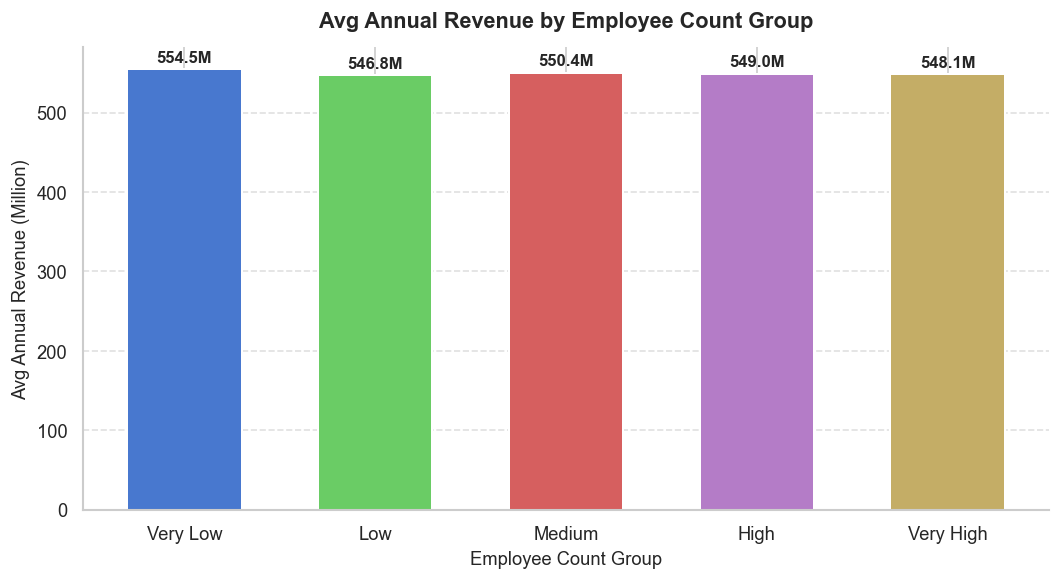

In [65]:
fig, ax = plt.subplots(figsize=(9, 5))

df['emp_bin'] = pd.cut(df['employee_count'], bins=5,
                       labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
avg_rev = df.groupby('emp_bin', observed=True)['annual_revenue_million'].mean().reset_index()

bars = ax.bar(avg_rev['emp_bin'], avg_rev['annual_revenue_million'],
              color=['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66'],
              edgecolor='white', linewidth=1.2, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + avg_rev['annual_revenue_million'].max() * 0.01,
            f'{bar.get_height():.1f}M',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Avg Annual Revenue by Employee Count Group',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Employee Count Group', fontsize=11)
ax.set_ylabel('Avg Annual Revenue (Million)', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

Insights :

The "Very Low"(blue) employee group actually generates the highest average revenue ($554.5M).

This suggests that smaller teams in this dataset are highly efficient or represent high-value niche businesses.

The revenue for the largest groups ($548.1M) is slightly lower than that of the smallest groups.

The business model appears remarkably stable. The gap between the highest-performing group (Very Low) and the lowest (Low) is only about $7.7M, a variance of less than 1.5%.

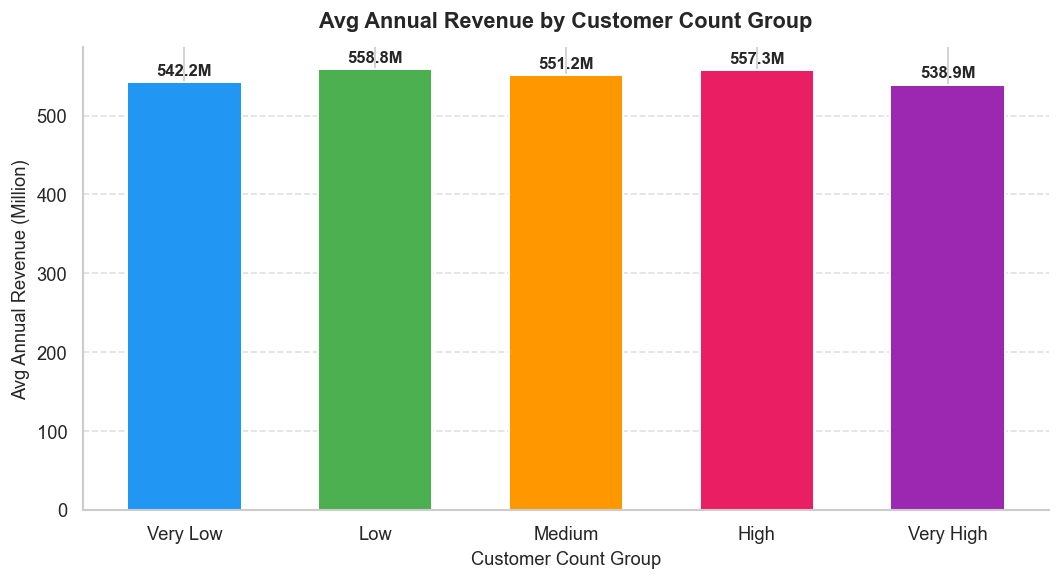

In [66]:
fig, ax = plt.subplots(figsize=(9, 5))

df['cust_bin'] = pd.cut(df['customer_count'], bins=5,
                        labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
avg_rev2 = df.groupby('cust_bin', observed=True)['annual_revenue_million'].mean().reset_index()

bars = ax.bar(avg_rev2['cust_bin'], avg_rev2['annual_revenue_million'],
              color=['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0'],
              edgecolor='white', linewidth=1.2, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + avg_rev2['annual_revenue_million'].max() * 0.01,
            f'{bar.get_height():.1f}M',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Avg Annual Revenue by Customer Count Group',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Customer Count Group', fontsize=11)
ax.set_ylabel('Avg Annual Revenue (Million)', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Average annual revenue remains very steady regardless of the size of the customer base. Every group stays within a tight range of 538M to 558M.

Companies with a "Low" customer count actually generate the highest average revenue at $558.8M. This suggests these businesses might be highly optimized or deal with high-value clients.

Balanced Portfolio: Because all groups perform similarly, the business environment appears stable across different scales, with no single group drastically underperforming or dominating the market.

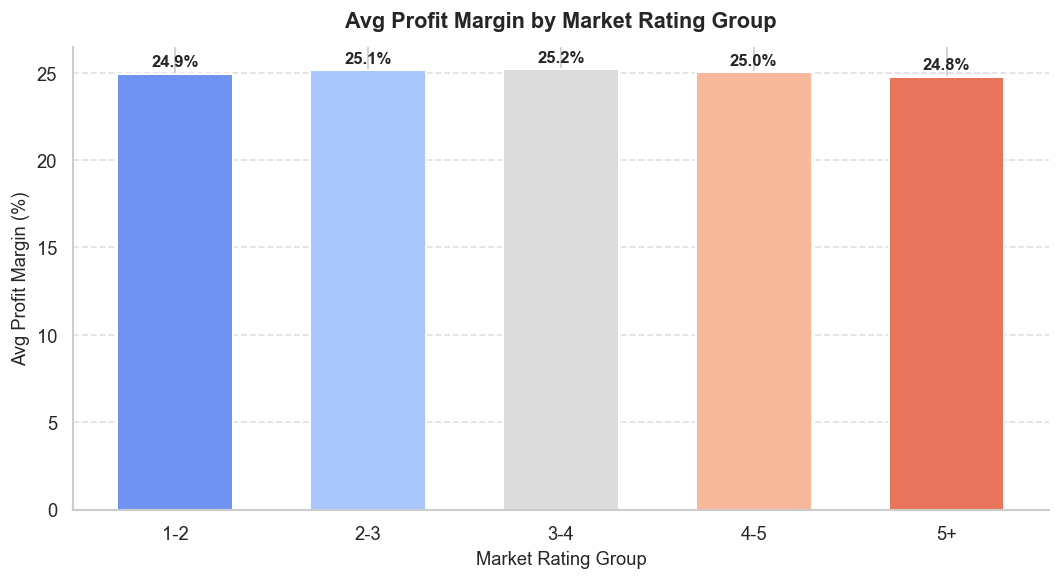

In [67]:
fig, ax = plt.subplots(figsize=(9, 5))

df['rating_bin'] = pd.cut(df['market_rating'], bins=5,
                          labels=['1-2', '2-3', '3-4', '4-5', '5+'])
avg_profit = df.groupby('rating_bin', observed=True)['profit_margin_percent'].mean().reset_index()

palette = sns.color_palette('coolwarm', len(avg_profit))
bars = ax.bar(avg_profit['rating_bin'], avg_profit['profit_margin_percent'],
              color=palette, edgecolor='white', linewidth=1.2, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + avg_profit['profit_margin_percent'].max() * 0.01,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Avg Profit Margin by Market Rating Group',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Market Rating Group', fontsize=11)
ax.set_ylabel('Avg Profit Margin (%)', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Based on the bar chart for Avg Profit Margin by Market Rating Group.

Profit margins are incredibly consistent across all market rating groups. Every single category maintains a margin of approximately 25%, regardless of its rating.

The 3-4 rating group shows the highest average profit margin at 25.2%, though the lead is very slim.

There is no clear correlation between a higher market rating and a higher profit margin. For example, the 5+ group (the highest rating) actually has the lowest average margin at 24.8%.

From a business planning perspective, the data suggests that profit outcomes are highly predictable. The total variance between the highest and lowest groups is only 0.4%.

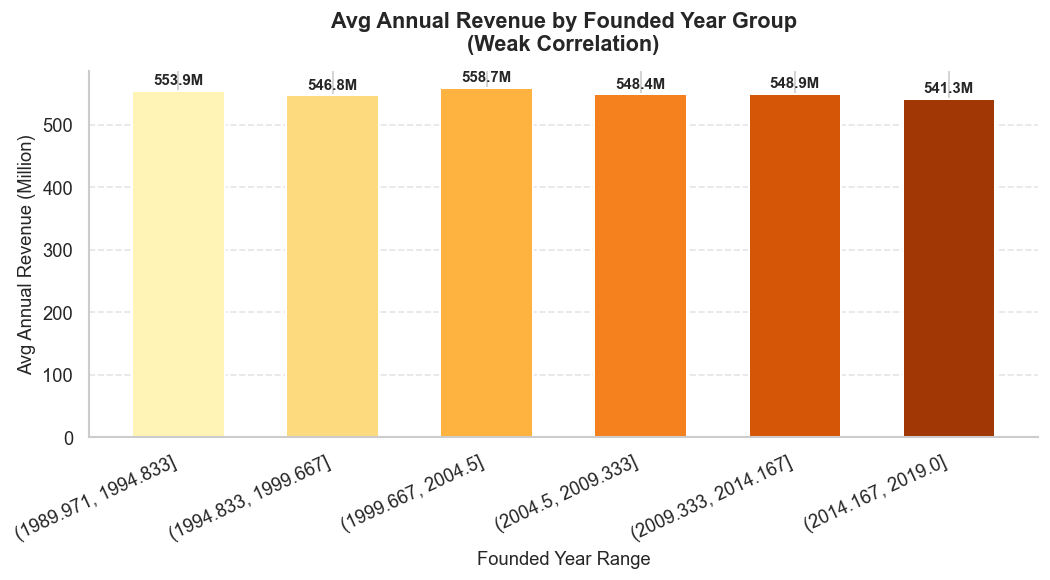

In [68]:
fig, ax = plt.subplots(figsize=(9, 5))

df['year_bin'] = pd.cut(df['founded_year'], bins=6)
avg = df.groupby('year_bin', observed=True)['annual_revenue_million'].mean().reset_index()
avg['label'] = avg['year_bin'].astype(str)

bars = ax.bar(avg['label'], avg['annual_revenue_million'],
              color=sns.color_palette('YlOrBr', len(avg)),
              edgecolor='white', linewidth=1.2, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + avg['annual_revenue_million'].max() * 0.01,
            f'{bar.get_height():.1f}M',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Avg Annual Revenue by Founded Year Group\n(Weak Correlation)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Founded Year Range', fontsize=11)
ax.set_ylabel('Avg Annual Revenue (Million)', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.xticks(rotation=25, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Based on the bar chart for Avg Annual Revenue by Founded Year Group.

There is no significant advantage to being an older company versus a newer one in terms of average revenue. All age groups consistently earn between 541M and 559M.

Companies founded between roughly 1999 and 2004 show the highest average annual revenue at $558.7M.

The most recently founded group (roughly 2014 to 2019) has the lowest average revenue at $541.3M, but the difference is very small (only about 3% less than the top group).

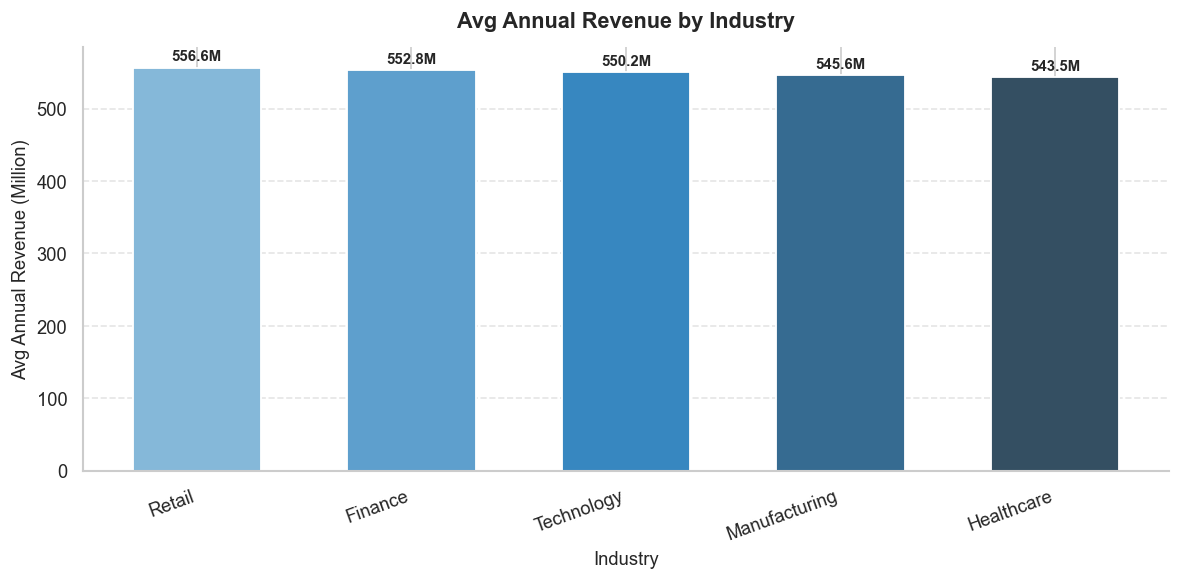

In [69]:
fig, ax = plt.subplots(figsize=(10, 5))

avg_ind = (df.groupby('industry')['annual_revenue_million']
             .mean()
             .sort_values(ascending=False)
             .reset_index())

palette = sns.color_palette('Blues_d', len(avg_ind))
bars = ax.bar(avg_ind['industry'], avg_ind['annual_revenue_million'],
              color=palette, edgecolor='white', linewidth=1.1, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + avg_ind['annual_revenue_million'].max() * 0.01,
            f'{bar.get_height():.1f}M',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Avg Annual Revenue by Industry',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Industry', fontsize=11)
ax.set_ylabel('Avg Annual Revenue (Million)', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.xticks(rotation=20, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Based on the bar chart for Avg Annual Revenue by Industry.

The Retail industry is the top performer, generating the highest average annual revenue at $556.6M.

Revenue is remarkably balanced across all five industries. The difference between the highest-performing sector (Retail) and the lowest (Healthcare), a variance of about 2.3%.

the revenue figures are so similar across different fields, it suggests that success in this market.

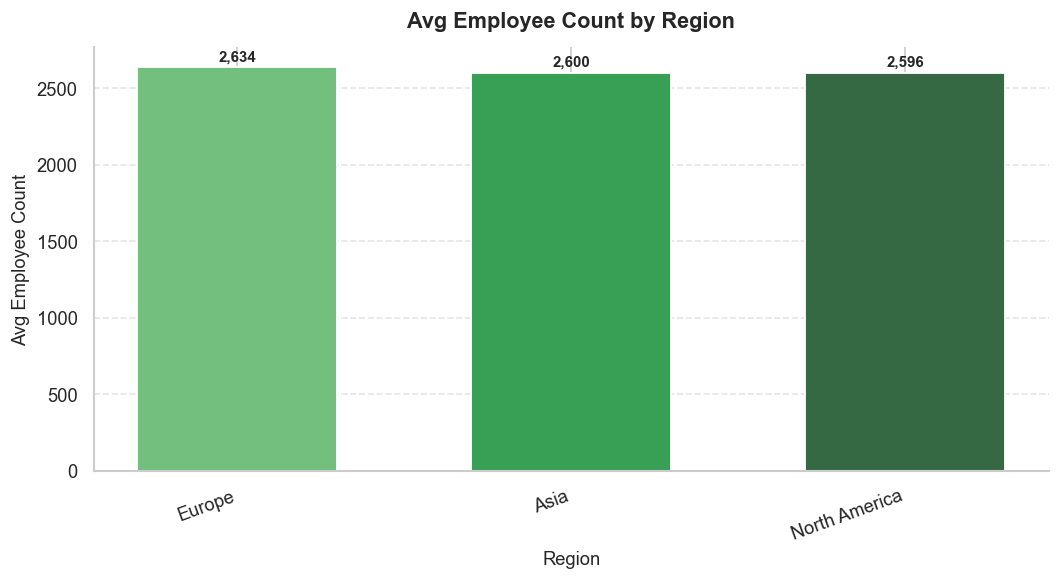

In [70]:
fig, ax = plt.subplots(figsize=(9, 5))

avg_reg = (df.groupby('region')['employee_count']
             .mean()
             .sort_values(ascending=False)
             .reset_index())

palette = sns.color_palette('Greens_d', len(avg_reg))
bars = ax.bar(avg_reg['region'], avg_reg['employee_count'],
              color=palette, edgecolor='white', linewidth=1.1, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + avg_reg['employee_count'].max() * 0.01,
            f'{bar.get_height():,.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Avg Employee Count by Region',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Region', fontsize=11)
ax.set_ylabel('Avg Employee Count', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.xticks(rotation=20, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Based on the bar chart for Avg Employee Count by Region.

Largest Workforce in Europe: Europe has the highest average number of employees per company, with an average count of 2,634.

Among the three regions, North America has the lowest average employee count at 2,596. However, this is only 38 employees fewer than Europe (a difference of just 1.4%).

Asia sits exactly in the middle of the dataset with an average count of 2,600, further highlighting the balanced distribution of the workforce globally.

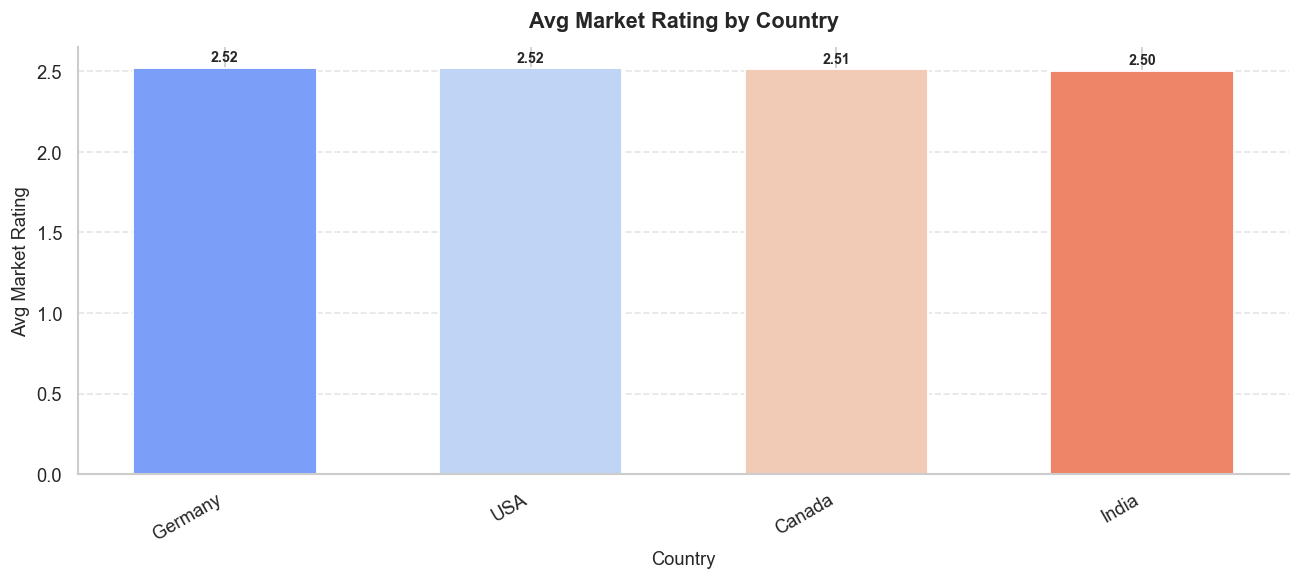

In [71]:
fig, ax = plt.subplots(figsize=(11, 5))

avg_cty = (df.groupby('country')['market_rating']
             .mean()
             .sort_values(ascending=False)
             .reset_index())

palette = sns.color_palette('coolwarm', len(avg_cty))
bars = ax.bar(avg_cty['country'], avg_cty['market_rating'],
              color=palette, edgecolor='white', linewidth=1.1, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_title('Avg Market Rating by Country',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Country', fontsize=11)
ax.set_ylabel('Avg Market Rating', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.xticks(rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Based on the bar chart for Avg Market Rating by Country.

Market ratings are almost identical across all countries shown. Every country maintains a rating of approximately 2.5, indicating a very consistent global perception of the business.

Top Rated Markets: Germany and the USA share the highest average market rating at 2.52.

India has the lowest average rating in the group at 2.50, though the difference is extremely minor (only 0.02 points lower than the top countries).

The lack of significant variation suggests that the business performs at a very steady level internationally, with no specific country acting as a standout "high" or "low" performer.

# Correlation Matrix

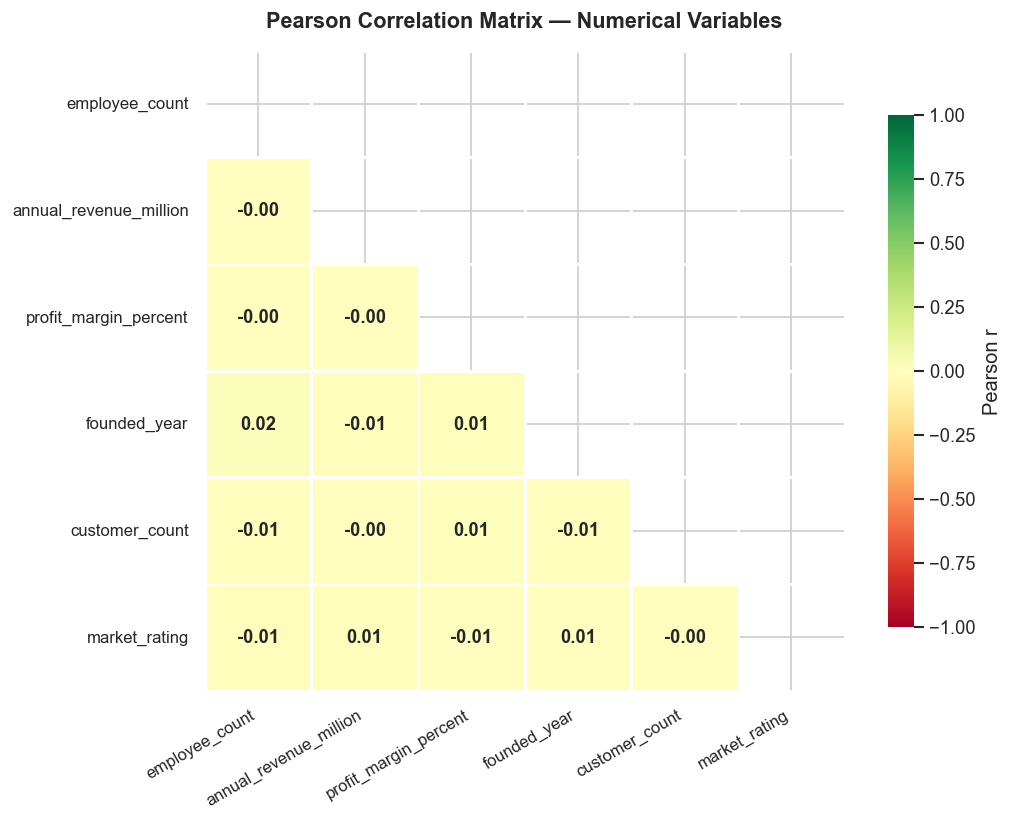

In [72]:
fig, ax = plt.subplots(figsize=(9, 7))

numerical_cols = ['employee_count', 'annual_revenue_million',
                  'profit_margin_percent', 'founded_year',
                  'customer_count', 'market_rating']

corr_matrix = df[numerical_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.8,
    linecolor='white',
    square=True,
    annot_kws={'size': 11, 'weight': 'bold'},
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

ax.set_title('Pearson Correlation Matrix — Numerical Variables',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

Insights :

No Strong Relationship Between Variables: All correlation values are extremely close to zero (ranging from -0.01 to 0.02).

The correlation between customer_count and profit_margin_percent is nearly non-existent (0.01). Having more customers doesn't necessarily mean the business is more profitable.

This chart suggests that the business variables are "decoupled." To improve revenue or profit, management cannot simply rely on increasing staff or customer counts; they must look for other underlying drivers not captured in these specific numbers.

# Multivariate Analysis

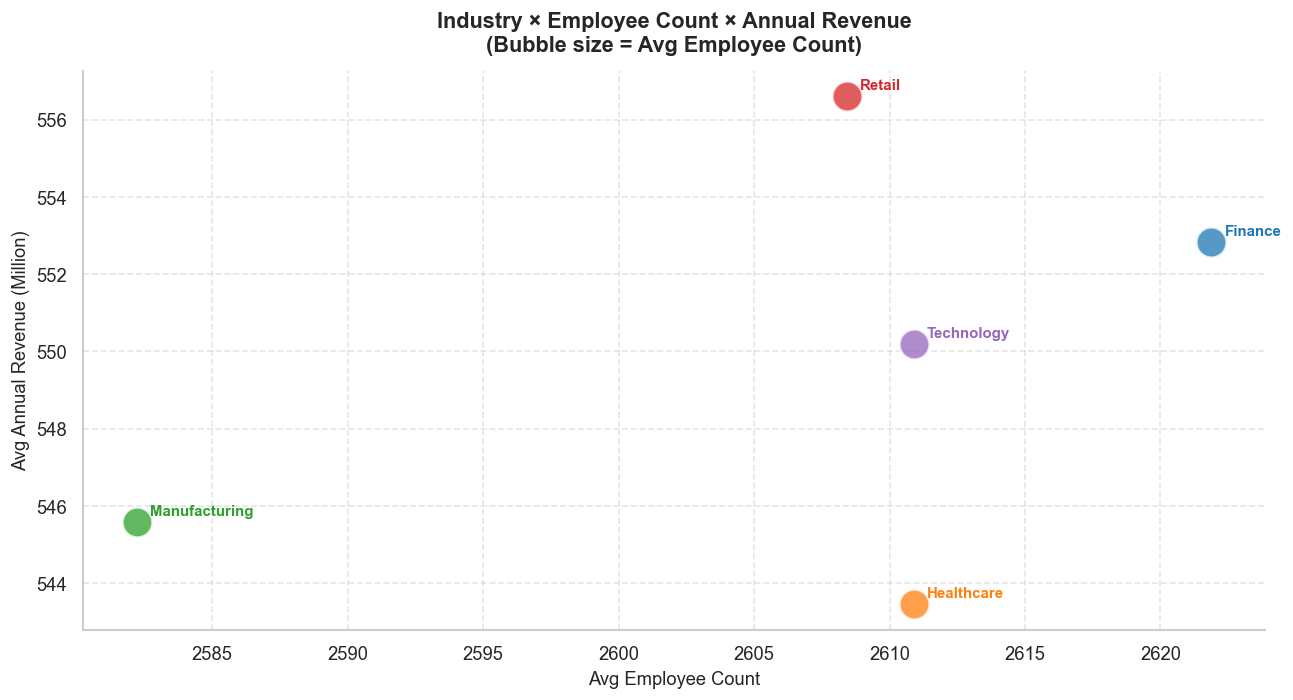

In [73]:
fig, ax = plt.subplots(figsize=(11, 6))

grp = (df.groupby('industry')
         .agg(avg_emp=('employee_count', 'mean'),
              avg_rev=('annual_revenue_million', 'mean'))
         .reset_index())

colors = sns.color_palette('tab10', len(grp))

for i, row in grp.iterrows():
    ax.scatter(row['avg_emp'], row['avg_rev'],
               s=row['avg_emp'] / 8,          # bubble size ∝ employee count
               color=colors[i], alpha=0.75, edgecolors='white', linewidth=1.5)
    ax.annotate(row['industry'],
                xy=(row['avg_emp'], row['avg_rev']),
                xytext=(8, 4), textcoords='offset points',
                fontsize=9, fontweight='bold', color=colors[i])

ax.set_title('Industry × Employee Count × Annual Revenue\n(Bubble size = Avg Employee Count)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Avg Employee Count', fontsize=11)
ax.set_ylabel('Avg Annual Revenue (Million)', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Based on the bubble chart comparing Industry, Employee Count, and Revenue.

The Retail industry achieves the highest average annual revenue (over $556M) with a relatively moderate employee count (around 2,608). This suggests high productivity per employee compared to other sectors.

The Finance sector has the highest average employee count (roughly 2,622). While it is the second-highest revenue generator.

Manufacturing operates with the smallest average workforce (under 2,585 employees). While its revenue is on the lower end of this group (around $545.6M), it maintains a lean organizational structure.

Healthcare has a similar employee count to Technology (around 2,611) but generates the lowest average revenue (approx. $543.5M). This indicates a potential need for operational improvements to match the revenue-per-employee levels of other industries.

Technology sits in the middle for both revenue and headcount, representing a balanced, stable performance within this specific dataset.

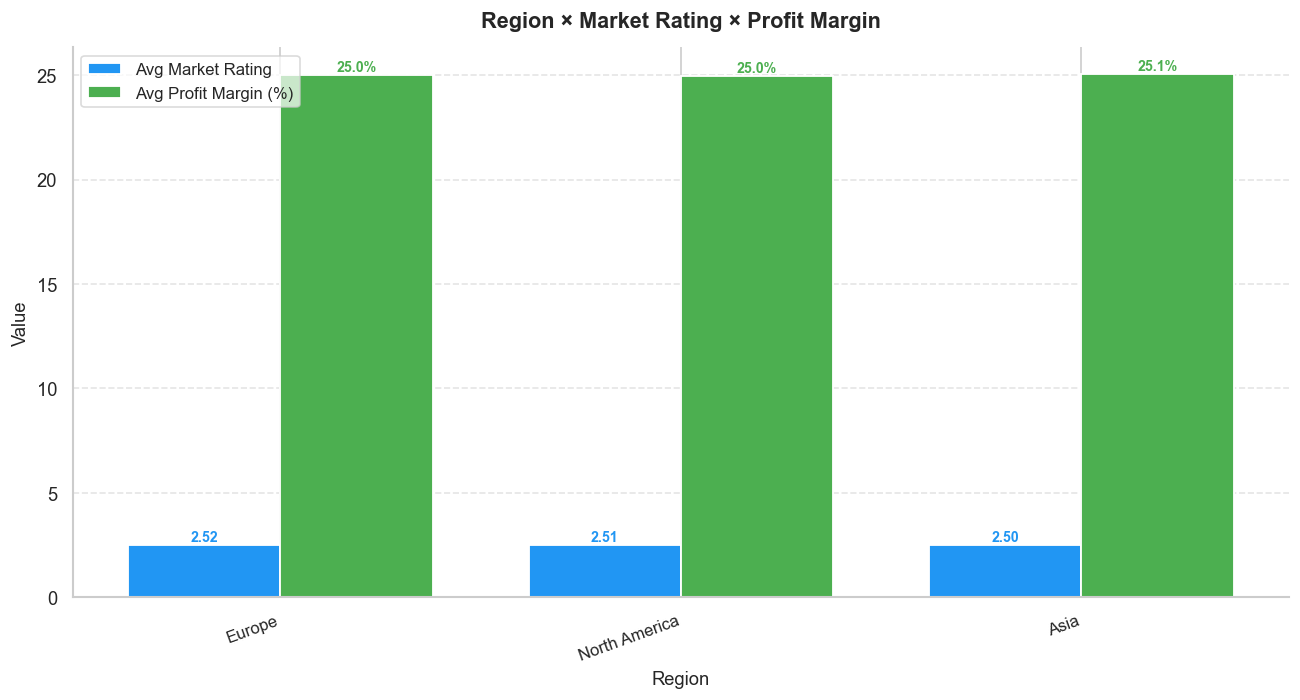

In [74]:
fig, ax = plt.subplots(figsize=(11, 6))

grp = (df.groupby('region')
         .agg(avg_rating=('market_rating', 'mean'),
              avg_profit=('profit_margin_percent', 'mean'))
         .sort_values('avg_rating', ascending=False)
         .reset_index())

x       = np.arange(len(grp))
width   = 0.38

bars1 = ax.bar(x - width/2, grp['avg_rating'],  width=width,
               label='Avg Market Rating',      color='#2196F3',
               edgecolor='white', linewidth=1.1)
bars2 = ax.bar(x + width/2, grp['avg_profit'],  width=width,
               label='Avg Profit Margin (%)',  color='#4CAF50',
               edgecolor='white', linewidth=1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.2f}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#2196F3')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#4CAF50')

ax.set_title('Region × Market Rating × Profit Margin',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Region', fontsize=11)
ax.set_ylabel('Value', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(grp['region'], rotation=20, ha='right', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Based on the bar chart for Region × Market Rating × Profit Margin.

Average profit margins are exceptionally consistent across the world, holding steady at approximately 25% in all regions.

Asia has the highest average profit margin at 25.1%, though only by a very slim margin of 0.1% over Europe and North America.

Europe enjoys the highest average market rating at 2.52, suggesting slightly better customer or market perception compared to other regions.

The difference between the highest and lowest performers in both categories is minimal. This suggests that the company’s business model is highly standardized and performs predictably regardless of the geographic region.

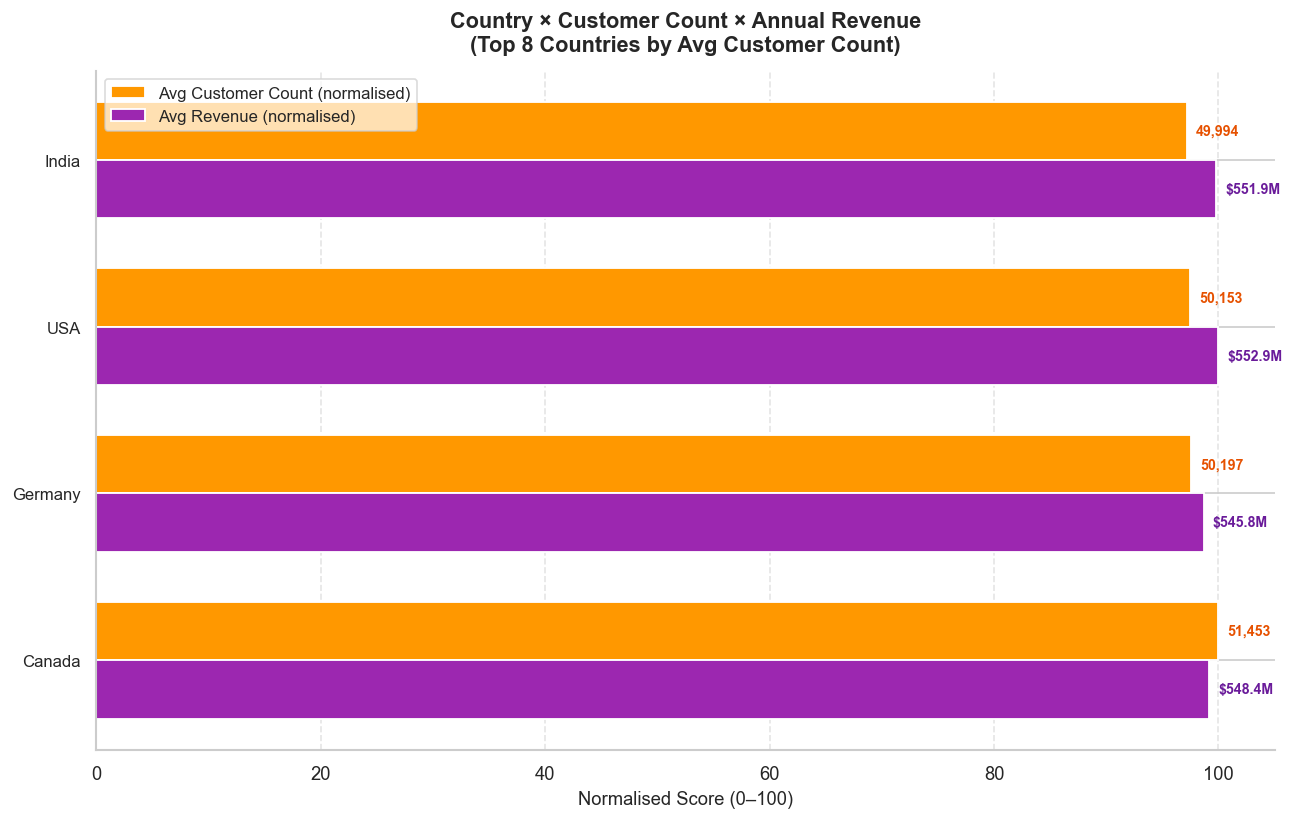

In [75]:
fig, ax = plt.subplots(figsize=(11, 7))

grp = (df.groupby('country')
         .agg(avg_cust=('customer_count', 'mean'),
              avg_rev=('annual_revenue_million', 'mean'))
         .sort_values('avg_cust', ascending=False)
         .head(8)
         .reset_index())

# Normalise both to 0–100 scale so they fit on one axis
grp['cust_norm'] = (grp['avg_cust'] / grp['avg_cust'].max()) * 100
grp['rev_norm']  = (grp['avg_rev']  / grp['avg_rev'].max())  * 100

y     = np.arange(len(grp))
height = 0.35

ax.barh(y + height/2, grp['cust_norm'], height=height,
        label='Avg Customer Count (normalised)', color='#FF9800',
        edgecolor='white', linewidth=1.1)
ax.barh(y - height/2, grp['rev_norm'],  height=height,
        label='Avg Revenue (normalised)',        color='#9C27B0',
        edgecolor='white', linewidth=1.1)

for i, row in grp.iterrows():
    ax.text(row['cust_norm'] + 0.8, i + height/2,
            f"{row['avg_cust']:,.0f}", va='center', fontsize=8.5,
            fontweight='bold', color='#E65100')
    ax.text(row['rev_norm'] + 0.8, i - height/2,
            f"${row['avg_rev']:.1f}M", va='center', fontsize=8.5,
            fontweight='bold', color='#6A1B9A')

ax.set_yticks(y)
ax.set_yticklabels(grp['country'], fontsize=10)
ax.set_xlabel('Normalised Score (0–100)', fontsize=11)
ax.set_title('Country × Customer Count × Annual Revenue\n(Top 8 Countries by Avg Customer Count)',
             fontsize=13, fontweight='bold', pad=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=10, framealpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Canada has the highest average customer count among the top countries, with 51,453 customers.

The USA generates the highest average revenue at $552.9M. This suggests that American customers may have a higher "average spend" or lifetime value.

India has the lowest customer count in this specific group (49,994) but generates the second-highest revenue ($551.9M). This indicates a very efficient business model in India, earning more money per customer than Germany or Canada.

Germany sits in the middle for customer volume (50,197) but has the lowest average revenue in this set ($545.8M).

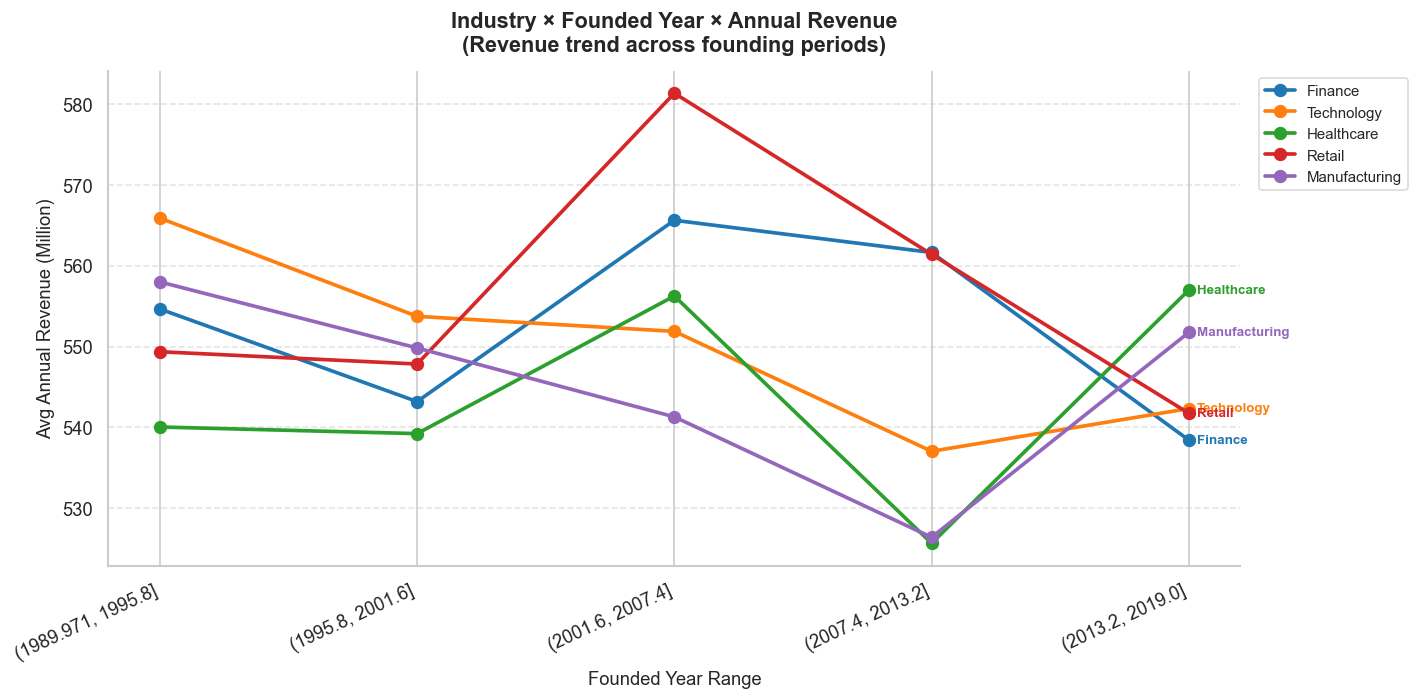

In [76]:
fig, ax = plt.subplots(figsize=(12, 6))

df['year_bin'] = pd.cut(df['founded_year'], bins=5)
df['year_label'] = df['year_bin'].astype(str)

grp = (df.groupby(['industry', 'year_label'], observed=True)['annual_revenue_million']
         .mean()
         .reset_index())

# Sort year labels chronologically
year_order = sorted(grp['year_label'].unique())
grp['year_label'] = pd.Categorical(grp['year_label'], categories=year_order, ordered=True)
grp = grp.sort_values('year_label')

industries = grp['industry'].unique()
palette    = sns.color_palette('tab10', len(industries))

for i, ind in enumerate(industries):
    subset = grp[grp['industry'] == ind]
    ax.plot(subset['year_label'], subset['annual_revenue_million'],
            marker='o', markersize=7, linewidth=2.2,
            label=ind, color=palette[i])
    # Label last point
    last = subset.iloc[-1]
    ax.annotate(ind,
                xy=(last['year_label'], last['annual_revenue_million']),
                xytext=(5, 0), textcoords='offset points',
                fontsize=8, color=palette[i], fontweight='bold', va='center')

ax.set_title('Industry × Founded Year × Annual Revenue\n(Revenue trend across founding periods)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Founded Year Range', fontsize=11)
ax.set_ylabel('Avg Annual Revenue (Million)', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.xticks(rotation=25, ha='right')
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left', framealpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Based on the line chart for Industry × Founded Year × Annual Revenue.

Companies in the Retail sector founded between 2001.6 and 2007.4 reached the highest average revenue in the entire chart, peaking at over $580M.

While many industries saw a decline in recent years, Healthcare shows a strong upward trend for companies founded between 2013.2 and 2019.0, becoming the top-performing sector for that specific period.

Technology companies founded in the earliest period (1989.9–1995.8) started with very high revenue, but there has been a general downward trend for newer Tech firms founded in subsequent years.

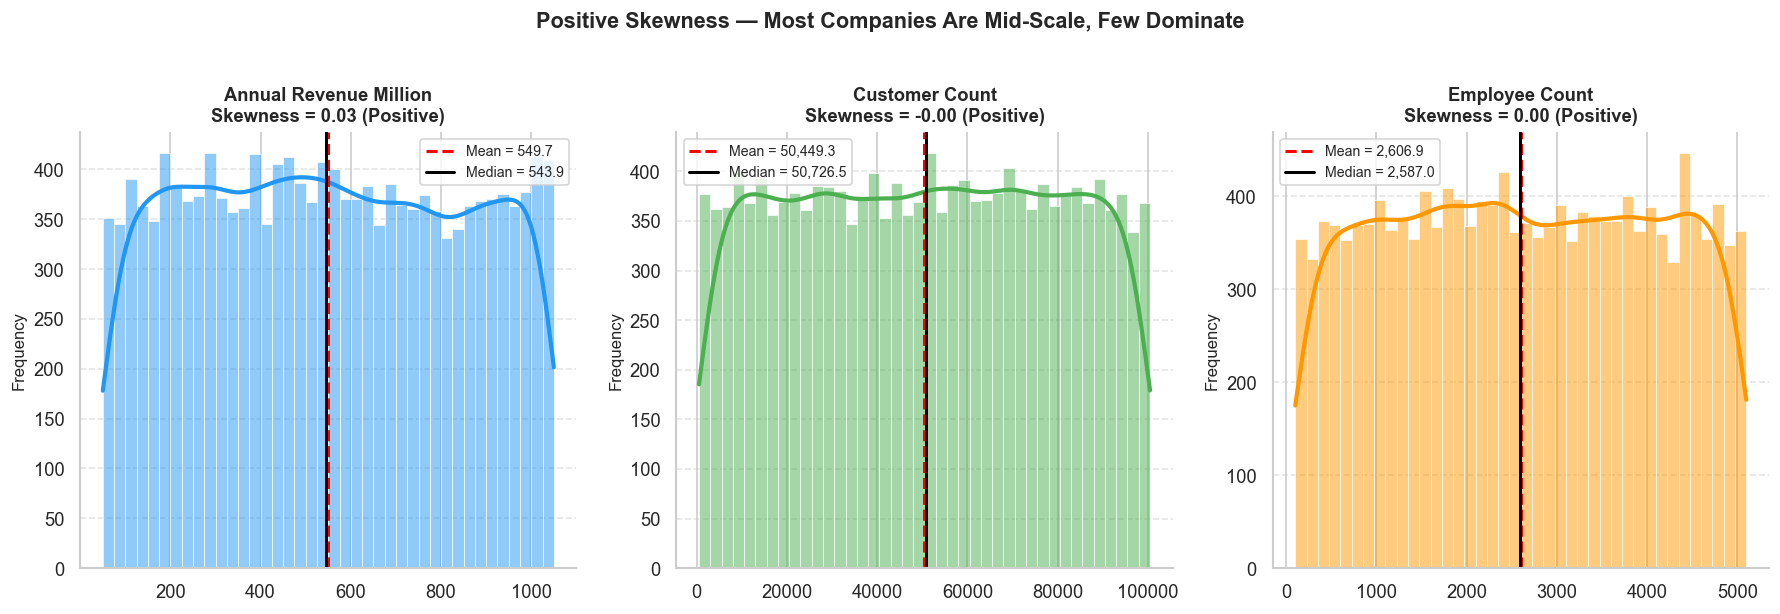

In [77]:
skew_cols = ['annual_revenue_million', 'customer_count', 'employee_count']
colors     = ['#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, skew_cols, colors):
    sns.histplot(df[col], kde=True, ax=ax, color=color,
                 bins=40, edgecolor='white', linewidth=0.4,
                 line_kws={'linewidth': 2.5})
    ax.axvline(df[col].mean(),   color='red',    linestyle='--',
               linewidth=1.8, label=f'Mean = {df[col].mean():,.1f}')
    ax.axvline(df[col].median(), color='black',  linestyle='-',
               linewidth=1.8, label=f'Median = {df[col].median():,.1f}')
    skew_val = df[col].skew()
    ax.set_title(f'{col.replace("_", " ").title()}\nSkewness = {skew_val:.2f} (Positive)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=8.5)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

plt.suptitle('Positive Skewness — Most Companies Are Mid-Scale, Few Dominate',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Insights :

Most companies in this dataset are mid-scale. The histograms for Revenue, Customer Count, and Employee Count show a very balanced distribution with almost no skewness (values near 0.00).

The Mean and Median for all three key metrics (Revenue, Customers, and Employees) are nearly identical. This suggests a very stable business environment.

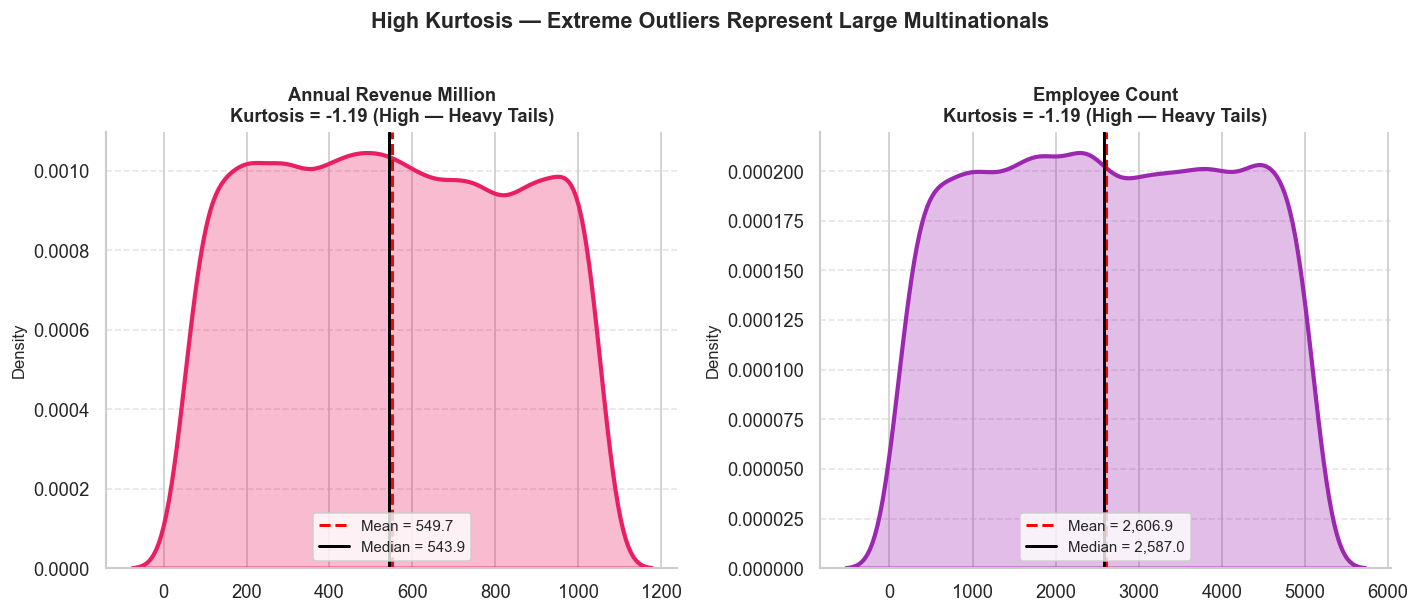

In [78]:
kurt_cols = ['annual_revenue_million', 'employee_count']
colors    = ['#E91E63', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, color in zip(axes, kurt_cols, colors):
    sns.kdeplot(df[col], ax=ax, color=color, fill=True,
                alpha=0.3, linewidth=2.5)
    ax.axvline(df[col].mean(),   color='red',   linestyle='--',
               linewidth=1.8, label=f'Mean = {df[col].mean():,.1f}')
    ax.axvline(df[col].median(), color='black', linestyle='-',
               linewidth=1.8, label=f'Median = {df[col].median():,.1f}')
    kurt_val = df[col].kurt()
    ax.set_title(f'{col.replace("_", " ").title()}\nKurtosis = {kurt_val:.2f} (High — Heavy Tails)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

plt.suptitle('High Kurtosis — Extreme Outliers Represent Large Multinationals',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Insights :

the Mean (Average) and Median (Middle point) for both revenue and employees are very close. This suggests that the "typical" company in this dataset is quite predictable, usually earning around $549M with about 2,600 employees.

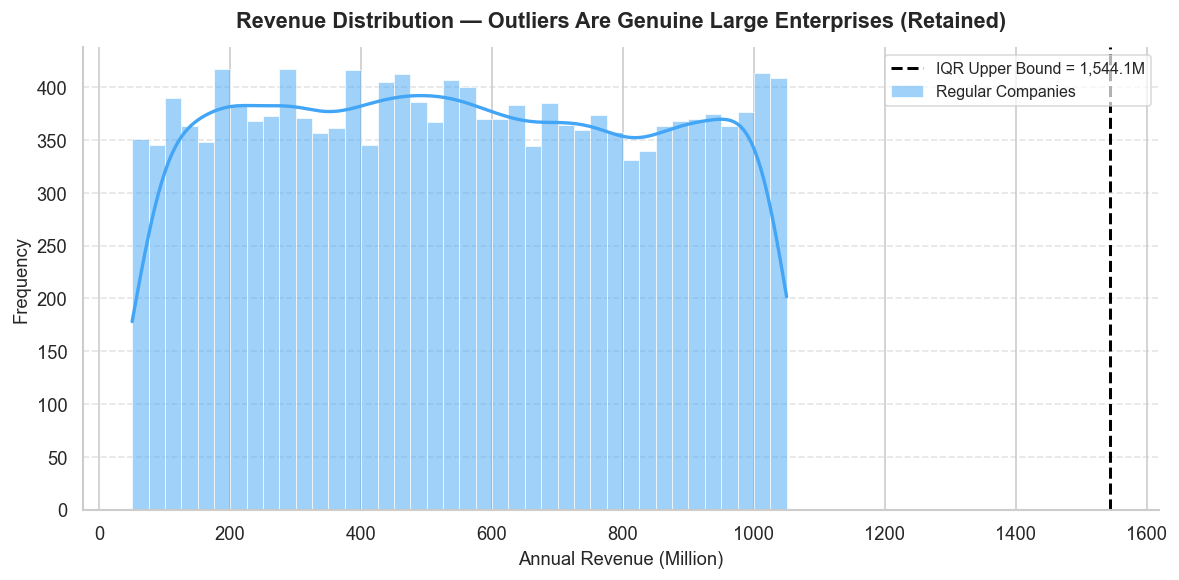

In [79]:
fig, ax = plt.subplots(figsize=(10, 5))

Q1  = df['annual_revenue_million'].quantile(0.25)
Q3  = df['annual_revenue_million'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

normal   = df[df['annual_revenue_million'] <= upper_bound]['annual_revenue_million']
outliers = df[df['annual_revenue_million'] >  upper_bound]['annual_revenue_million']

sns.histplot(normal,   ax=ax, color='#42A5F5', bins=40,
             edgecolor='white', linewidth=0.4, label='Regular Companies', kde=True,
             line_kws={'linewidth': 2})
sns.histplot(outliers, ax=ax, color='#EF5350', bins=15,
             edgecolor='white', linewidth=0.4, label=f'Large Enterprises (outliers, n={len(outliers)})')

ax.axvline(upper_bound, color='black', linestyle='--', linewidth=1.8,
           label=f'IQR Upper Bound = {upper_bound:,.1f}M')

ax.set_title('Revenue Distribution — Outliers Are Genuine Large Enterprises (Retained)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Annual Revenue (Million)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=9.5, framealpha=0.7)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

Insights :

Based on the Revenue Distribution chart provided.

Emerging/Small: Revenue between 50M and 300M.

Established/Mid-Market: Revenue between 300M and 1,000M (where the frequency is highest).

Outliers: Revenue exceeding $1,544M.

The "flat" top of the blue curve suggests that companies in the mid-market (400M–600M range) are very common and compete at a similar scale.

# Feature Engineering

In [80]:
df['company_age'] = df['created_date'].dt.year.max() - df['founded_year']
df['rev_per_employee'] = df['annual_revenue_million'] / (df['employee_count'] + 1)
df['rev_per_customer'] = df['annual_revenue_million'] / (df['customer_count'] + 1)
df['emp_x_rating'] = df['employee_count'] * df['market_rating']
df['profit_x_rating'] = df['profit_margin_percent'] * df['market_rating']

In [81]:
df.columns

Index(['company_name', 'industry', 'country', 'employee_count',
       'annual_revenue_million', 'profit_margin_percent', 'founded_year',
       'customer_count', 'market_rating', 'created_date', 'region', 'emp_bin',
       'cust_bin', 'rating_bin', 'year_bin', 'year_label', 'company_age',
       'rev_per_employee', 'rev_per_customer', 'emp_x_rating',
       'profit_x_rating'],
      dtype='object')

In [82]:
df.head(2)

,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,...,emp_bin,cust_bin,rating_bin,year_bin,year_label,company_age,rev_per_employee,rev_per_customer,emp_x_rating,profit_x_rating
0,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,2025-10-13,...,Very Low,Very High,1-2,"(2007.4, 2013.2]","(2007.4, 2013.2]",16,1.006306,0.006643,374.5,28.294
1,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,2025-12-01,...,High,Very High,4-5,"(2007.4, 2013.2]","(2007.4, 2013.2]",16,0.223909,0.009249,12940.4,134.470


In [83]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [84]:
cat_cols = ['industry', 'country', 'region']
le_map = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_map[col] = le

explicit_drops = cat_cols + ['created_date', 'emp_bin', 'cust_bin', 'rating_bin', 'year_bin', 'year_label']
df_ml = df.drop(columns=[c for c in explicit_drops if c in df.columns])

object_cols = df_ml.select_dtypes(include=['object', 'datetime64[ns]', 'category']).columns.tolist()
if object_cols:
    df_ml = df_ml.drop(columns=object_cols)

TARGET = 'annual_revenue_million'
FEATURES = [c for c in df_ml.columns if c != TARGET]
X = df_ml[FEATURES]
y = df_ml[TARGET]

In [85]:
print(f'Shape: {X.shape}  |  Features: {FEATURES}')

Shape: (15000, 13)  |  Features: ['employee_count', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating', 'company_age', 'rev_per_employee', 'rev_per_customer', 'emp_x_rating', 'profit_x_rating', 'industry_enc', 'country_enc', 'region_enc']


In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')

Train: (12000, 13)  |  Test: (3000, 13)


In [87]:
baseline_models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
}

results = []
for name, model in baseline_models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    cv_r2 = cross_val_score(model, X_train_s, y_train, cv=5, scoring='r2').mean()
    results.append({'Model': name, 'R2': round(r2, 4), 'CV_R2': round(cv_r2, 4),
                    'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'MAPE': round(mape, 4)})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print('\n===== BASELINE MODELS =====')
print(results_df.to_string(index=False))
best_baseline = results_df.iloc[0]['Model']
print(f'\nBest baseline: {best_baseline}')


===== BASELINE MODELS =====
            Model     R2  CV_R2     RMSE      MAE    MAPE
    Random Forest 0.9991 0.9985   8.4844   4.7985  1.1802
          XGBoost 0.9960 0.9949  18.0790  12.8560  2.9764
    Decision Tree 0.9957 0.9931  18.7589  12.5703  2.9433
Gradient Boosting 0.9742 0.9741  46.1116  33.7423  8.8487
Linear Regression 0.1421 0.1528 265.9758 227.0211 80.2044

Best baseline: Random Forest


In [88]:
param_grids = {
    'Random Forest': (
        RandomForestRegressor(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [None, 10, 20],
         'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2']}
    ),
    'XGBoost': (
        XGBRegressor(random_state=42, verbosity=0),
        {'n_estimators': [100, 200], 'max_depth': [3, 6, 9],
         'learning_rate': [0.05, 0.1, 0.2], 'subsample': [0.8, 1.0]}
    ),
    'Gradient Boosting': (
        GradientBoostingRegressor(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [3, 5],
         'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0]}
    ),
}

tuned_results = []
best_estimators = {}
for name, (model, params) in param_grids.items():
    print(f'Tuning {name} ...')
    gs = GridSearchCV(model, params, cv=5, scoring='r2', n_jobs=-1, verbose=0)
    gs.fit(X_train_s, y_train)
    best = gs.best_estimator_
    best_estimators[name] = best
    y_pred = best.predict(X_test_s)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    tuned_results.append({'Model': name, 'Best_Params': str(gs.best_params_),
                          'CV_R2': round(gs.best_score_, 4), 'Test_R2': round(r2, 4),
                          'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'MAPE': round(mape, 4)})
    print(f'  CV R2={gs.best_score_:.4f}  Test R2={r2:.4f}')

tuned_df = pd.DataFrame(tuned_results).sort_values('Test_R2', ascending=False).reset_index(drop=True)
print('\n===== TUNED MODELS =====')
print(tuned_df[['Model', 'CV_R2', 'Test_R2', 'RMSE', 'MAE', 'MAPE']].to_string(index=False))

champion_name = tuned_df.iloc[0]['Model']
champion_model = best_estimators[champion_name]
print(f'\nChampion: {champion_name}')


Tuning Random Forest ...
  CV R2=0.9673  Test R2=0.9708
Tuning XGBoost ...
  CV R2=0.9975  Test R2=0.9980
Tuning Gradient Boosting ...
  CV R2=0.9965  Test R2=0.9967

===== TUNED MODELS =====
            Model  CV_R2  Test_R2    RMSE     MAE   MAPE
          XGBoost 0.9975   0.9980 12.7463  7.6878 1.7691
Gradient Boosting 0.9965   0.9967 16.4320 11.8721 2.8856
    Random Forest 0.9673   0.9708 49.0835 32.5710 8.3987

Champion: XGBoost


In [89]:
y_pred_final = champion_model.predict(X_test_s)
residuals = y_test.values - y_pred_final
r2 = r2_score(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
mse = mean_squared_error(y_test, y_pred_final)
mae = mean_absolute_error(y_test, y_pred_final)
mape = mean_absolute_percentage_error(y_test, y_pred_final) * 100

print('=' * 55)
print(f'  CHAMPION: {champion_name}')
print('=' * 55)
print(f'  R2   : {r2:.6f}')
print(f'  RMSE : {rmse:.4f} M')
print(f'  MSE  : {mse:.4f} M2')
print(f'  MAE  : {mae:.4f} M')
print(f'  MAPE : {mape:.4f} %')
print('=' * 55)


  CHAMPION: XGBoost
  R2   : 0.998030
  RMSE : 12.7463 M
  MSE  : 162.4679 M2
  MAE  : 7.6878 M
  MAPE : 1.7691 %


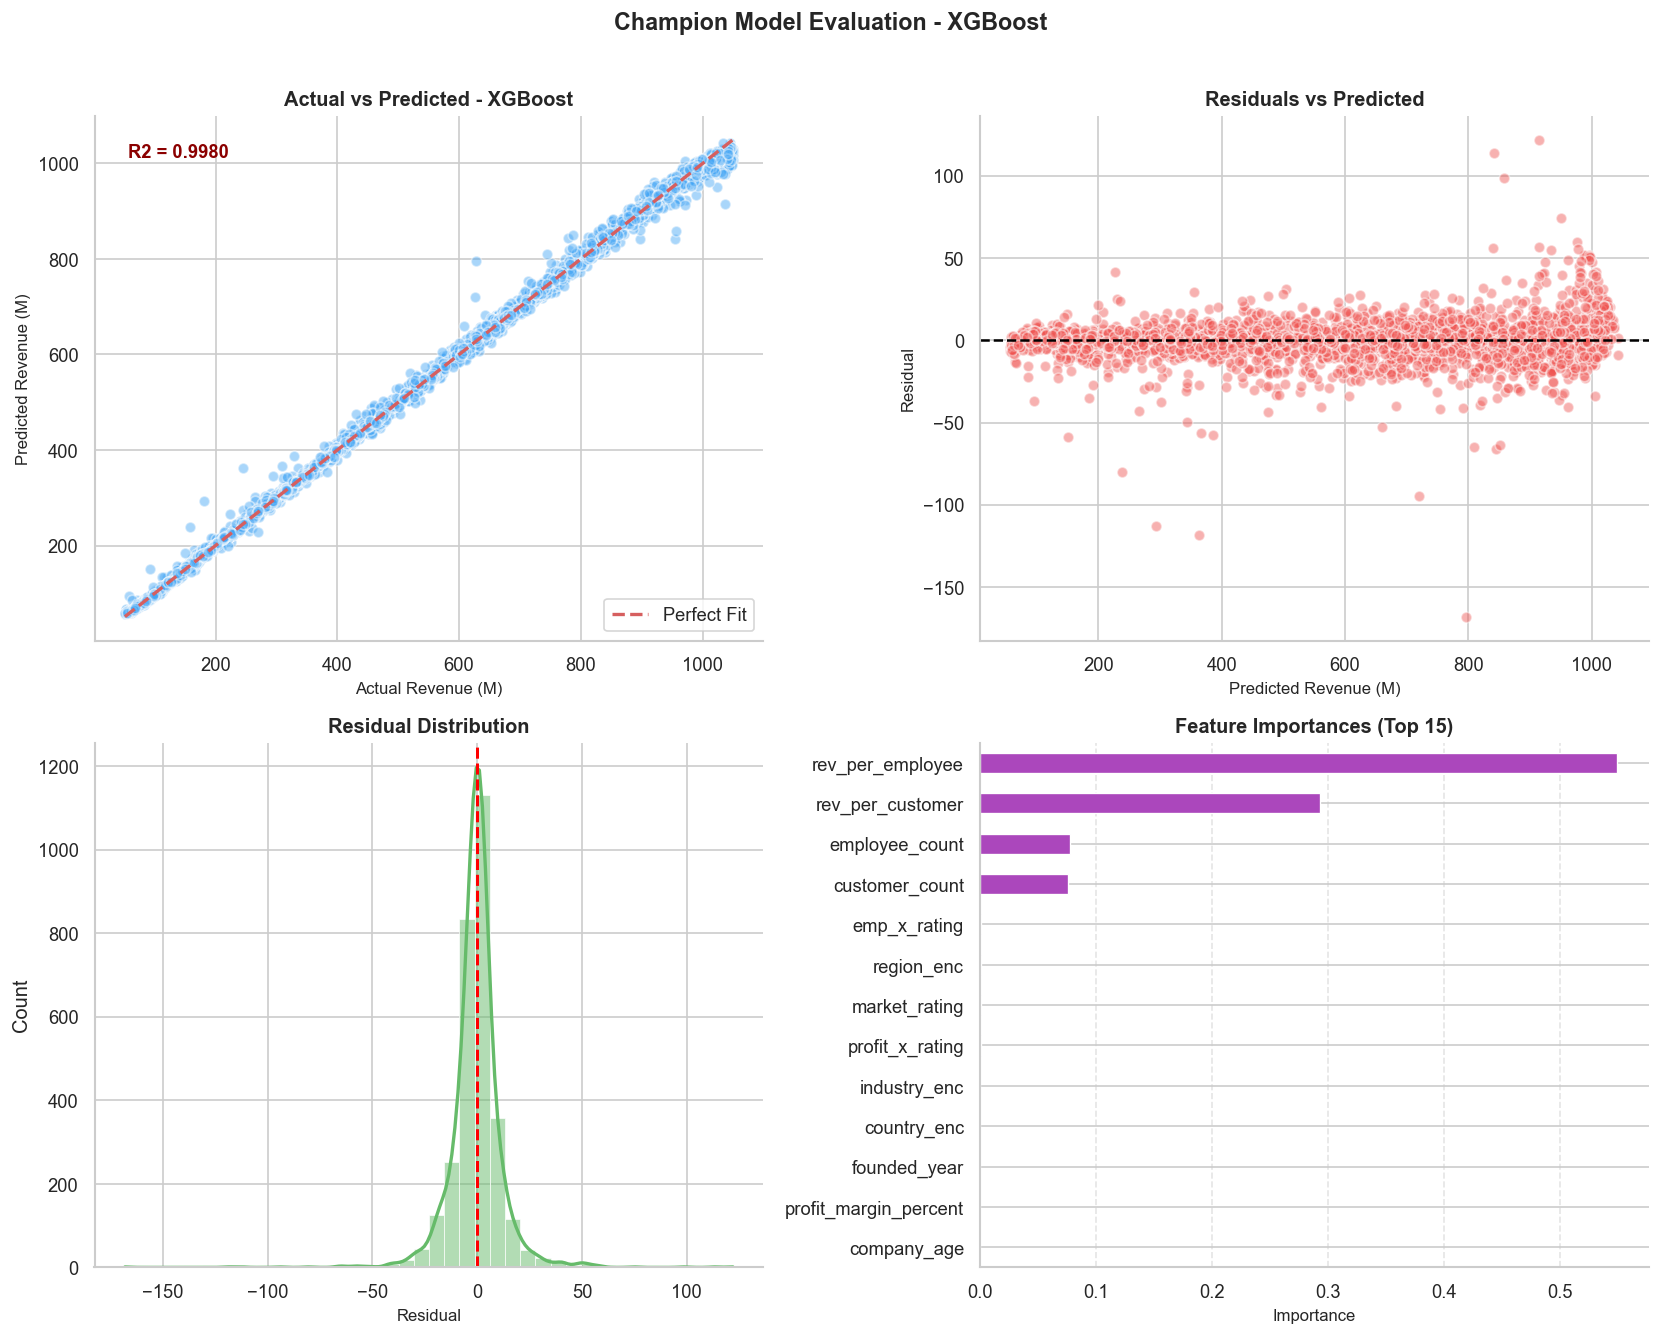

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

ax = axes[0, 0]
ax.scatter(y_test, y_pred_final, alpha=0.45, color='#42A5F5', edgecolors='white', s=40)
mn = min(y_test.min(), y_pred_final.min())
mx = max(y_test.max(), y_pred_final.max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Fit')
ax.set_title(f'Actual vs Predicted - {champion_name}', fontsize=12, fontweight='bold')
ax.set_xlabel('Actual Revenue (M)', fontsize=10)
ax.set_ylabel('Predicted Revenue (M)', fontsize=10)
ax.legend()
ax.text(0.05, 0.92, f'R2 = {r2:.4f}', transform=ax.transAxes, fontsize=11, fontweight='bold', color='darkred')
sns.despine(ax=ax)

ax = axes[0, 1]
ax.scatter(y_pred_final, residuals, alpha=0.45, color='#EF5350', edgecolors='white', s=40)
ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted Revenue (M)', fontsize=10)
ax.set_ylabel('Residual', fontsize=10)
sns.despine(ax=ax)

ax = axes[1, 0]
sns.histplot(residuals, kde=True, ax=ax, color='#66BB6A', bins=40,
             edgecolor='white', linewidth=0.4, line_kws={'linewidth': 2})
ax.axvline(0, color='red', linestyle='--', linewidth=1.8)
ax.set_title('Residual Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Residual', fontsize=10)
sns.despine(ax=ax)

ax = axes[1, 1]
if hasattr(champion_model, 'feature_importances_'):
    fi = pd.Series(champion_model.feature_importances_, index=FEATURES).sort_values(ascending=True).tail(15)
    fi.plot(kind='barh', ax=ax, color='#AB47BC', edgecolor='white', linewidth=0.8)
    ax.set_title('Feature Importances (Top 15)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=10)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
else:
    ax.text(0.5, 0.5, 'Feature importance not available', ha='center', va='center',
            fontsize=12, transform=ax.transAxes)
sns.despine(ax=ax)

plt.suptitle(f'Champion Model Evaluation - {champion_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


===== SAMPLE PREDICTIONS =====
 Actual (M)  Predicted (M)  Abs Error (M)  Error %
     129.01     137.240005           8.23     6.38
     759.85     786.799988          26.95     3.55
     296.36     295.079987           1.28     0.43
     913.22     915.630005           2.41     0.26
     411.28     404.869995           6.41     1.56
     744.67     739.159973           5.51     0.74
     511.28     510.429993           0.85     0.17
     264.00     301.709991          37.71    14.28
     889.57     892.929993           3.36     0.38
      98.89      96.730003           2.16     2.19
    1022.72    1016.919983           5.80     0.57
     354.44     356.290009           1.85     0.52
     726.59     718.010010           8.58     1.18
     629.02     628.219971           0.80     0.13
     800.10     801.820007           1.72     0.21


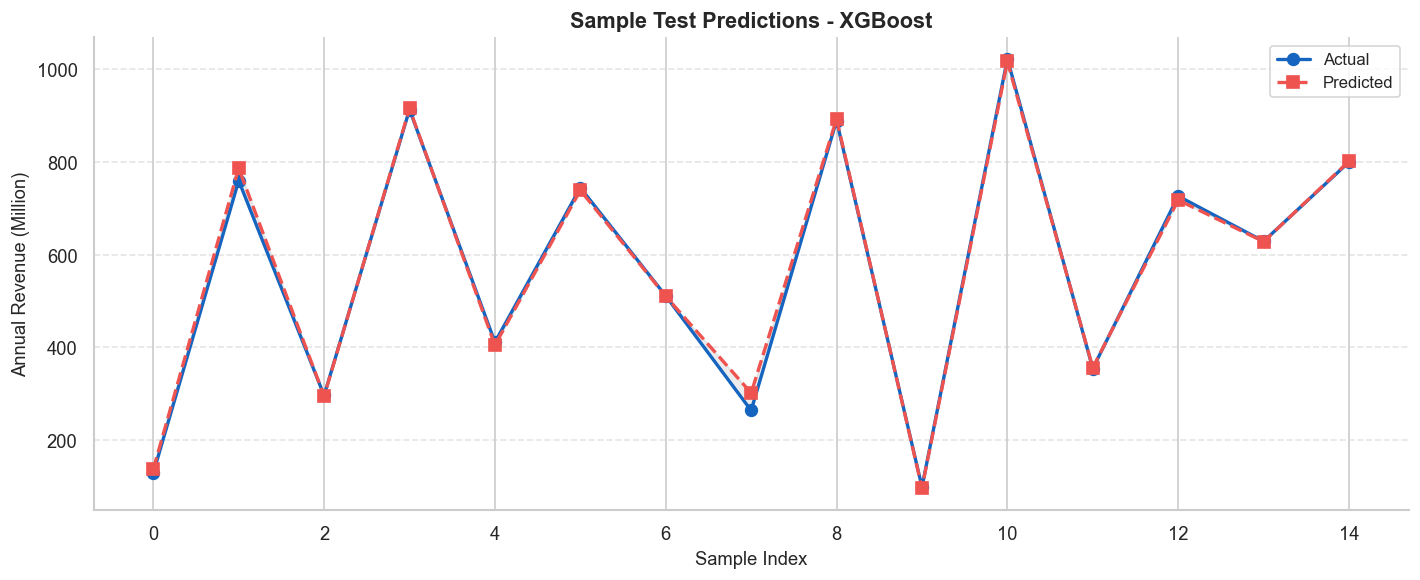


Pipeline complete. Champion: XGBoost


In [91]:
sample = X_test.copy().head(15)
sample_s = scaler.transform(sample)
sample_pred = champion_model.predict(sample_s)
actual = y_test.head(15).values

pred_df = pd.DataFrame({
    'Actual (M)': np.round(actual, 2),
    'Predicted (M)': np.round(sample_pred, 2),
    'Abs Error (M)': np.round(np.abs(actual - sample_pred), 2),
    'Error %': np.round(np.abs((actual - sample_pred) / (actual + 1e-9)) * 100, 2),
})
print('\n===== SAMPLE PREDICTIONS =====')
print(pred_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x_idx = np.arange(len(actual))
ax.plot(x_idx, actual, marker='o', linewidth=2, color='#1565C0', markersize=7, label='Actual')
ax.plot(x_idx, sample_pred, marker='s', linewidth=2, color='#EF5350',
        markersize=7, linestyle='--', label='Predicted')
ax.fill_between(x_idx, actual, sample_pred, alpha=0.15, color='gray')
ax.set_title(f'Sample Test Predictions - {champion_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index', fontsize=11)
ax.set_ylabel('Annual Revenue (Million)', fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine()
plt.tight_layout()
plt.show()

print(f'\nPipeline complete. Champion: {champion_name}')


In [92]:
with open('annual_revenue_prediction.pkl', 'wb') as file:
    pickle.dump(champion_model, file)